<a href="https://colab.research.google.com/github/geeta-sanjay-t/Geeta-Sanjay-Torane/blob/main/SeoulBike_data_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name - Seoul Bike Data 🚴**
# **Project Type - EDA**
# **Presented by - Geeta Sanjay Torane**


# **▶ Project Summary**

# The **Seoul Bike Data** project **highlights how weather and time factors shape bike rental demand in the city.**

# By analyzing hourly data with features like **temperature, humidity, rainfall, snowfall, and holiday indicators.**

# The study shows that **rentals peak during commuting hours, rise in summer and autumn, and drop sharply in bad weather**.

# The temperature and seasonality emerging as the most influential drivers. Overall, the project provides clear **insights to improve bike availability, support urban mobility, and promote sustainable transport in Seoul.**

# **▶ Problem Statement**

# The core problem addressed in the Seoul Bike dataset is the **challenge of predicting hourly rental demand** so that bikes are available when and where people need them.

# Demand fluctuates based on weather conditions, seasons, holidays, and commuting hours, making it difficult to maintain an optimal supply. Without accurate forecasting, users may face shortages during peak times or excess bikes during low demand periods.

#  This project **aims to build reliable prediction models that help optimize bike distribution, improve urban mobility, and support sustainable transportation planning in Seoul.**

# **▶  Define Your Business Objective?**

# The business objective of the Seoul Bike dataset project is to **accurately forecast hourly rental demand** so that bike availability matches user needs across different times and weather conditions.

# By reduce shortages during peak hours, and avoid excess supply during low-demand periods. Ultimately, this supports **efficient urban mobility planning**, enhances customer satisfaction, and promotes **sustainable transportation solutions** in Seoul.

# **1. Know Your Data**

# ▶ Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ▶ Dataset Loading

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Data sets/SeoulBikeData .csv', encoding='latin1')

# ▶ Dataset first view

In [ ]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [ ]:
df.tail()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


# ▶ Dataset Rows & Columns count

In [ ]:
df.index

RangeIndex(start=0, stop=8760, step=1)

In [ ]:
print(df.shape)

(8760, 14)


In [ ]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')

# ▶ Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,8760,365,30/11/2018,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rented Bike Count,8760.0,NaN,NaN,NaN,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
Hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
Temperature(°C),8760.0,NaN,NaN,NaN,12.882922,11.944825,-17.8,3.5,13.7,22.5,39.4
Humidity(%),8760.0,NaN,NaN,NaN,58.226256,20.362413,0.0,42.0,57.0,74.0,98.0
Wind speed (m/s),8760.0,NaN,NaN,NaN,1.724909,1.0363,0.0,0.9,1.5,2.3,7.4
Visibility (10m),8760.0,NaN,NaN,NaN,1436.825799,608.298712,27.0,940.0,1698.0,2000.0,2000.0
Dew point temperature(°C),8760.0,NaN,NaN,NaN,4.073813,13.060369,-30.6,-4.7,5.1,14.8,27.2
Solar Radiation (MJ/m2),8760.0,NaN,NaN,NaN,0.569111,0.868746,0.0,0.0,0.01,0.93,3.52
Rainfall(mm),8760.0,NaN,NaN,NaN,0.148687,1.128193,0.0,0.0,0.0,0.0,35.0


# ▶ Duplicate Values

In [ ]:
duplicate_values = df.duplicated().value_counts()
duplicate_values

,count
False,8760


In [ ]:
unique_df=df.shape[0]
unique_df

8760

# ✅ I have found 8760 rows & 14 columns in dataset

# ✅ There is no duplicate values found

# ✅ 8760 is unique values

# ▶ Missing values / null values count
# we have to check null values in data frame

In [ ]:
null_values = df.isna()== True
null_values

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8756,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8757,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8758,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


# ▶ No null values found in dataset

# **Created New columns**

# ▶ Converting Date object into datetime

#  ▶  created seperate Day , Month , Year and WeekDay column

# ▶  Drop the date column


In [ ]:
df["Date"] = pd.to_datetime(df["Date"], format='%d/%m/%Y')

df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["WeekDay"] = df["Date"].dt.day_name()

df.drop("Date" , axis =1 ,inplace = True)



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rented Bike Count          8760 non-null   int64  
 1   Hour                       8760 non-null   int64  
 2   Temperature(°C)            8760 non-null   float64
 3   Humidity(%)                8760 non-null   int64  
 4   Wind speed (m/s)           8760 non-null   float64
 5   Visibility (10m)           8760 non-null   int64  
 6   Dew point temperature(°C)  8760 non-null   float64
 7   Solar Radiation (MJ/m2)    8760 non-null   float64
 8   Rainfall(mm)               8760 non-null   float64
 9   Snowfall (cm)              8760 non-null   float64
 10  Seasons                    8760 non-null   object 
 11  Holiday                    8760 non-null   object 
 12  Functioning Day            8760 non-null   object 
 13  Day                        8760 non-null   int32

In [ ]:
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Day,Month,Year,WeekDay
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017,Friday
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017,Friday
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017,Friday
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017,Friday
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017,Friday


# ▶ Reset index to view unique data

In [ ]:
df.reset_index()

,index,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Day,Month,Year,WeekDay
0,0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017,Friday
1,1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017,Friday
2,2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017,Friday
3,3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017,Friday
4,4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,8755,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,30,11,2018,Friday
8756,8756,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,30,11,2018,Friday
8757,8757,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,30,11,2018,Friday
8758,8758,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,30,11,2018,Friday


# **Unique values for each variable**

In [ ]:
a=df.apply(lambda col: col.unique())
print(a)

Rented Bike Count            [254, 204, 173, 107, 78, 100, 181, 460, 930, 4...
Hour                         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...
Temperature(°C)              [-5.2, -5.5, -6.0, -6.2, -6.4, -6.6, -7.4, -7....
Humidity(%)                  [37, 38, 39, 40, 36, 35, 27, 24, 21, 23, 25, 2...
Wind speed (m/s)             [2.2, 0.8, 1.0, 0.9, 2.3, 1.5, 1.3, 1.1, 0.5, ...
Visibility (10m)             [2000, 1928, 1996, 1936, 793, 1913, 1687, 1380...
Dew point temperature(°C)    [-17.6, -17.7, -18.6, -18.7, -19.5, -19.3, -19...
Solar Radiation (MJ/m2)      [0.0, 0.01, 0.23, 0.65, 0.94, 1.11, 1.16, 1.01...
Rainfall(mm)                 [0.0, 0.5, 1.0, 2.5, 0.1, 0.2, 0.3, 0.7, 1.6, ...
Snowfall (cm)                [0.0, 0.1, 0.3, 0.4, 0.2, 1.0, 0.9, 0.8, 0.7, ...
Seasons                                       [Winter, Spring, Summer, Autumn]
Holiday                                                  [No Holiday, Holiday]
Functioning Day                                     

# **Data Visualization**

# **✔ Chart no.1**

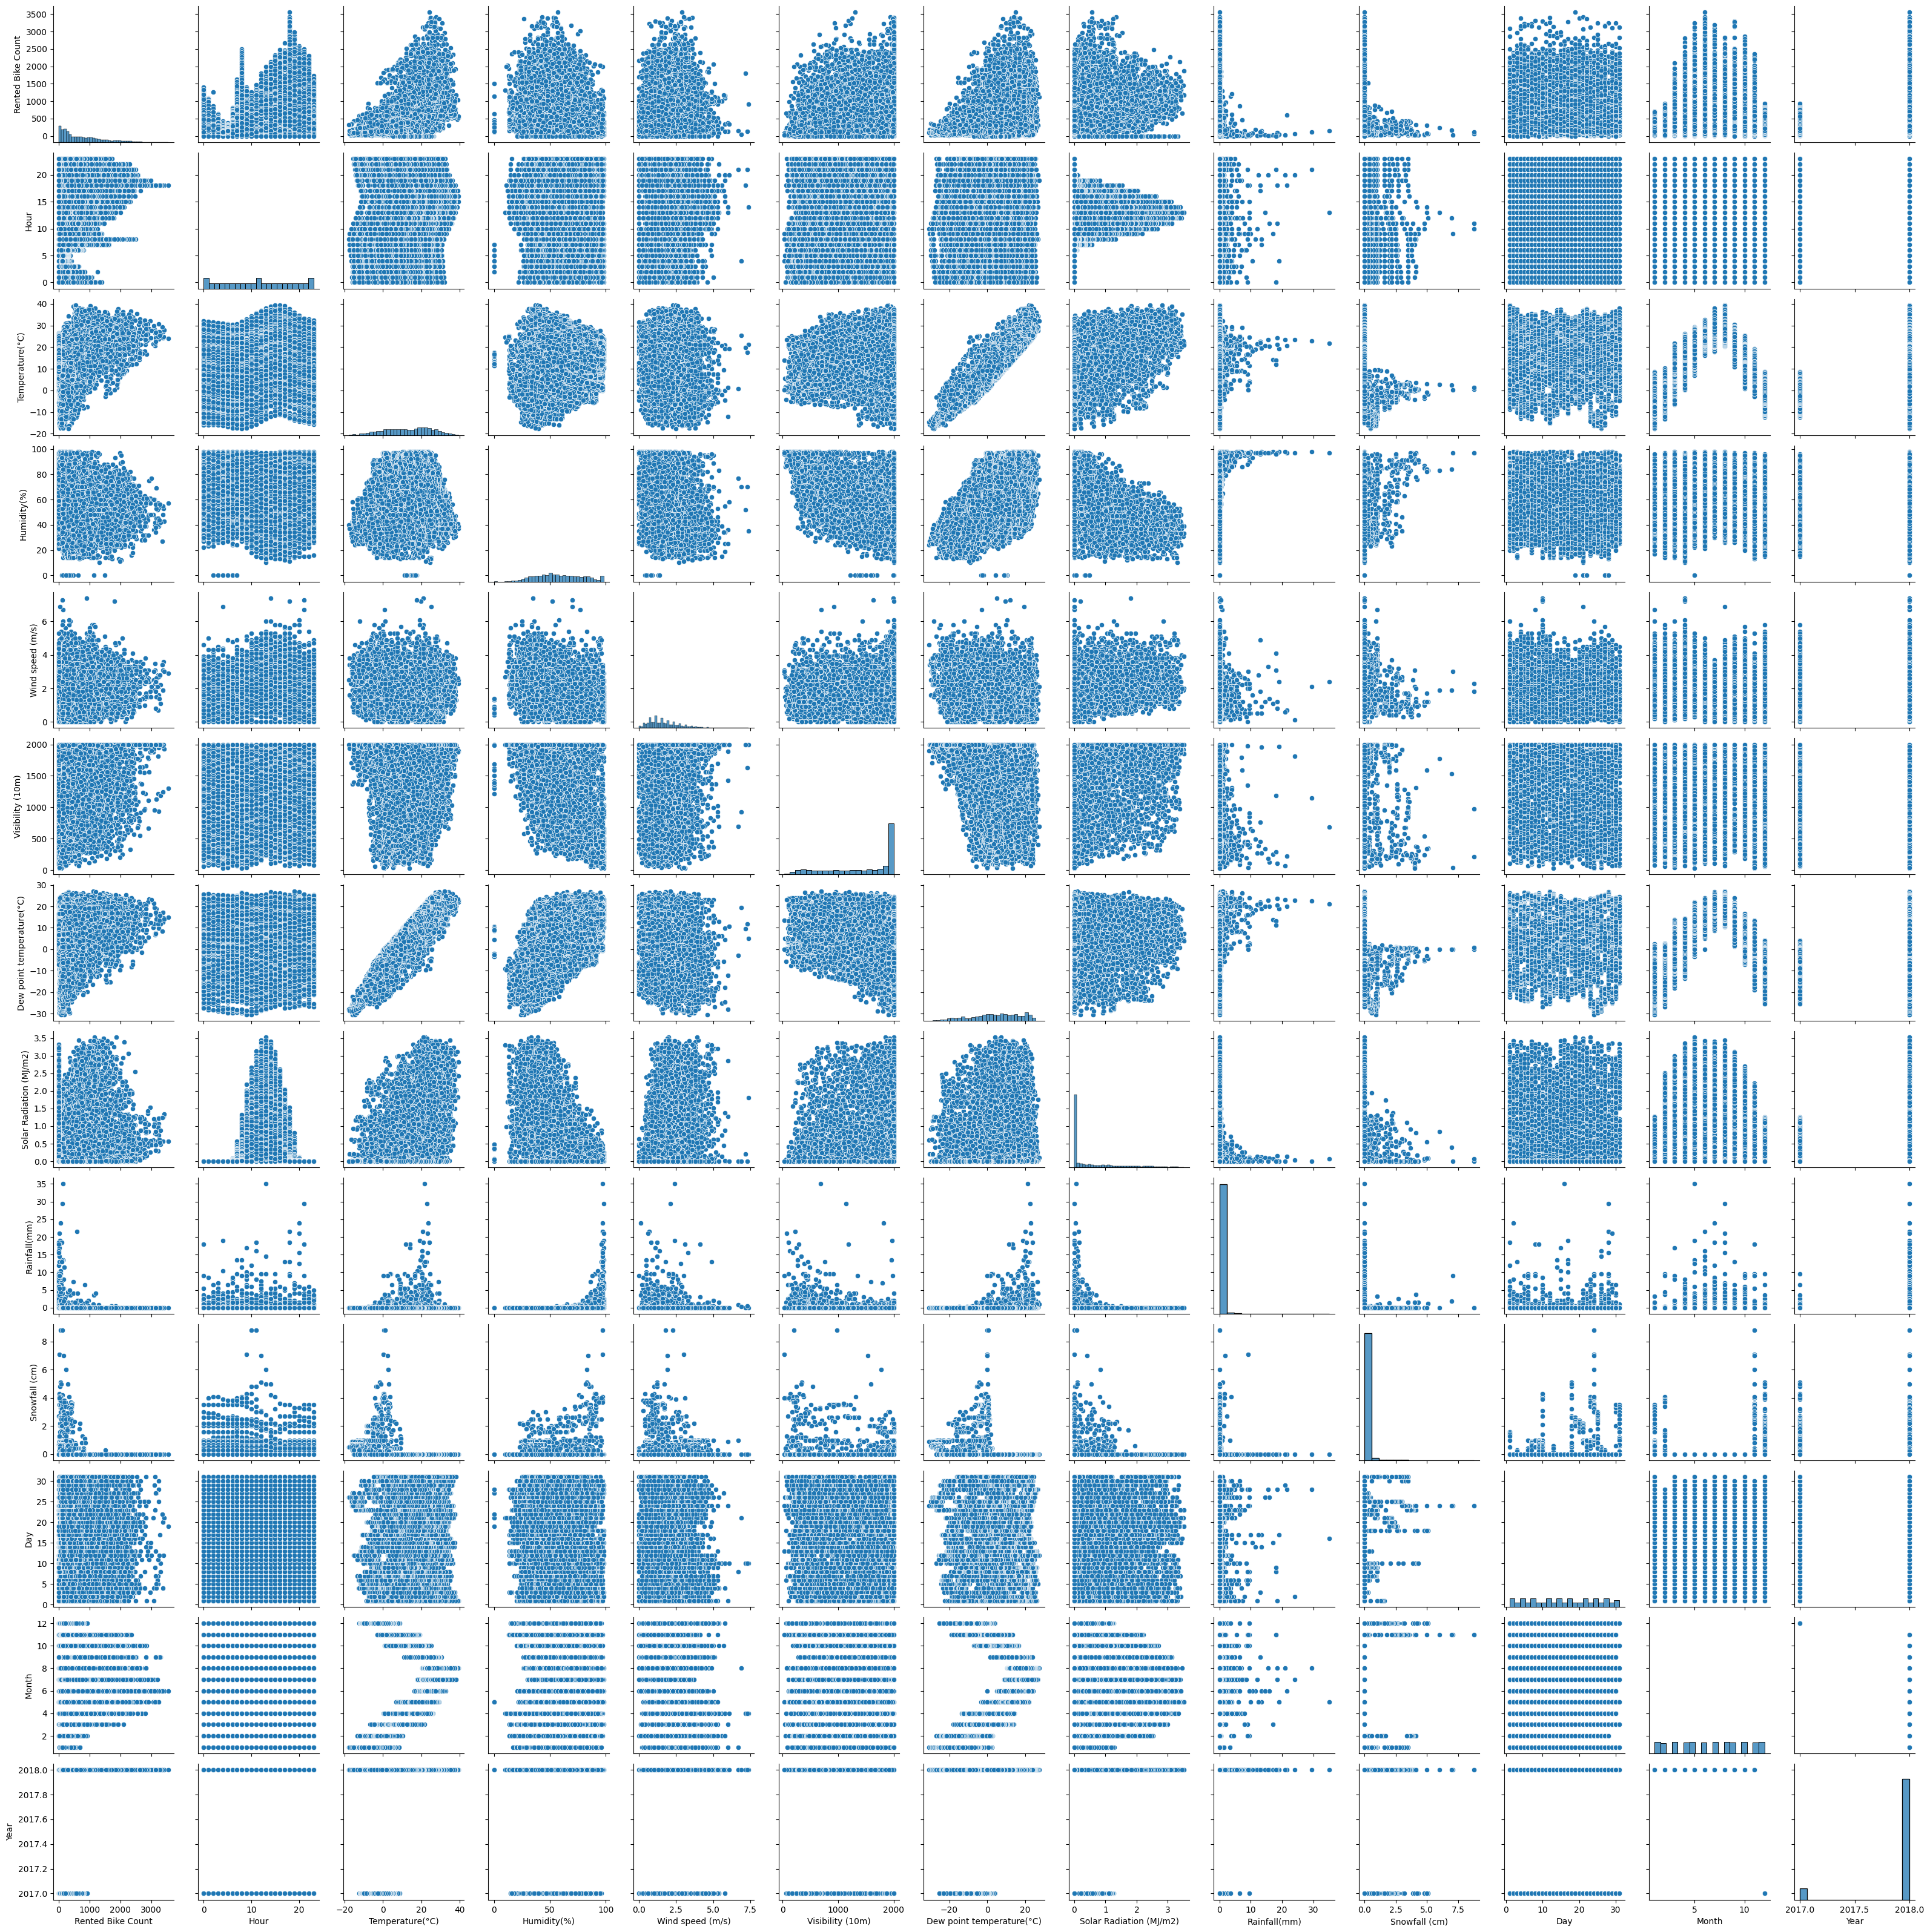

In [ ]:
sns.pairplot(df)

# ▶   Outcomes from above pairplot visualization

✅ From the above **pairplot** I found that in **year 2017 rented bike count decrease** & in **year 2018 rented bike count is increase.**

✅ In **month 2 & 10 bike demand decrease** and in **6th month bike demand increase.**

✅ whenever snowfall demand is increased between o to 4  & rainfall demand between 0 to 5 increase or equitable

✅ **we can say snowfall and rainfall not impacting drastically on demands of rented bike.**

✅ solar radiation and dew point temperature shows that **temperature decreases the bike demand increases.**



✅ As the visibility increases bike demand increase and vice versa of this.

✅ **Humidity between 20 to 80% demand is scale is high but at 0% low.**

✅wind speed not affecting much to bike demand.

✅ **Hour 18 and 8 shows  bike demand is high** but at **4 to 5 hour bike demand low.**

✅ **Rented bike demand in dataset showing decreasing.**

✅ **we have to take possible action to increase the demand.**

# **✔ Chart no.2**

<Axes: xlabel='Month', ylabel='Rented Bike Count'>

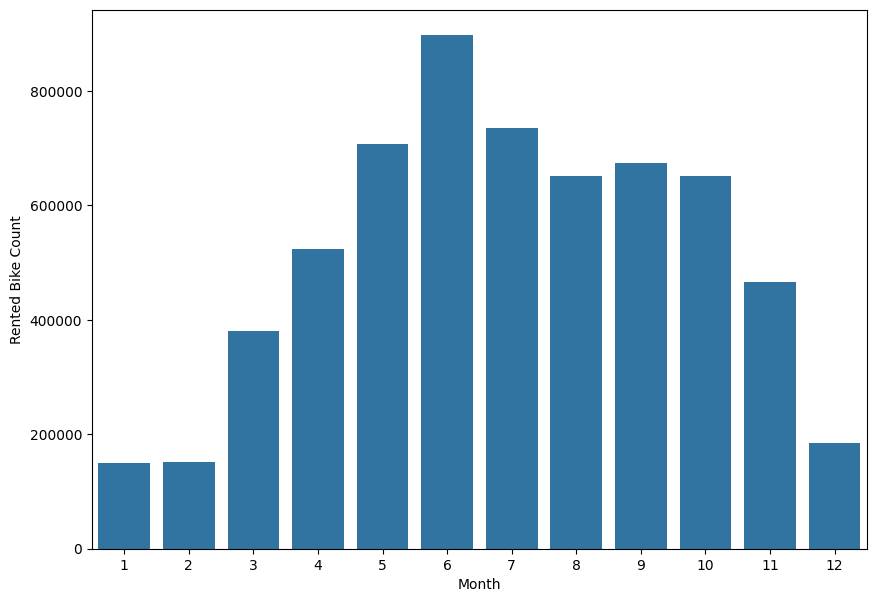

In [ ]:
Month = df.groupby("Month").sum()
plt.figure(figsize=(10,7))
sns.barplot(x= "Month" , y= "Rented Bike Count" , data= Month)

# ✅ Above barplot shows 6 that is **july month having highest number** of rented bike count and **growing market demand  during early summer .**

# ✅ month **january and february** showing **lowest demand of bike in seoul due to snowfall or other weather conditions reduces demand **.

# ✅ **High demand from May to October** as the favorable weather boosts usage.

# ✅ **Gradual rise from winter to summer, then decline toward winter** its clear seasonal pattern



# **✔ Chart no.3**

<Axes: xlabel='Day', ylabel='Rented Bike Count'>

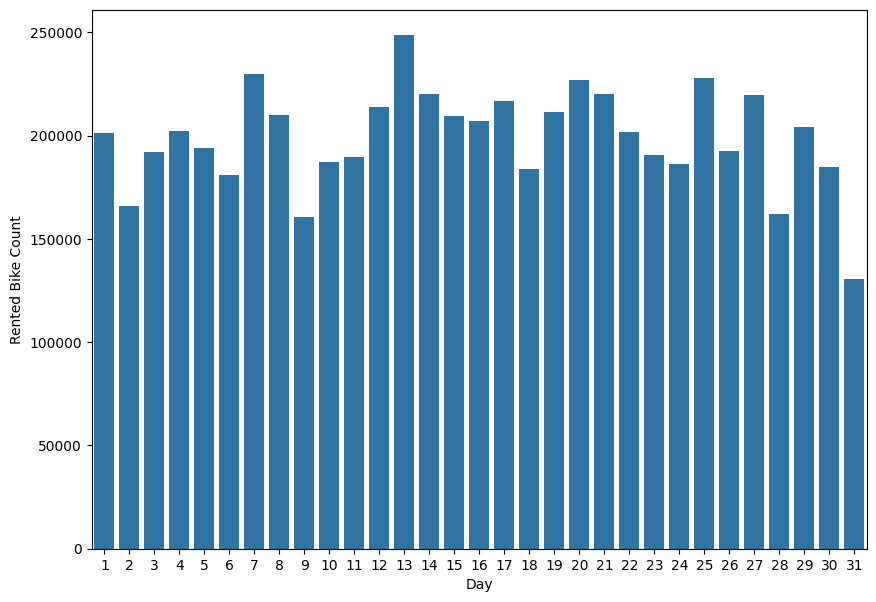

In [ ]:
Month = df.groupby("Day").sum()
plt.figure(figsize=(10,7))
sns.barplot(x= "Day" , y= "Rented Bike Count" , data= Month)

# ✅   **Day 13** showcasing **major demand  fairly consistent across days** of  rented bikes.

# ✅   **Day 9 and 31** shows **less demand** compare with other days.may be due to external factors (weather/holidays)

# ✅ **Slight peaks around mid-month (13-15, 20-25)** , possible salary period or increased activity



# **✔ Chart no.4**

<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

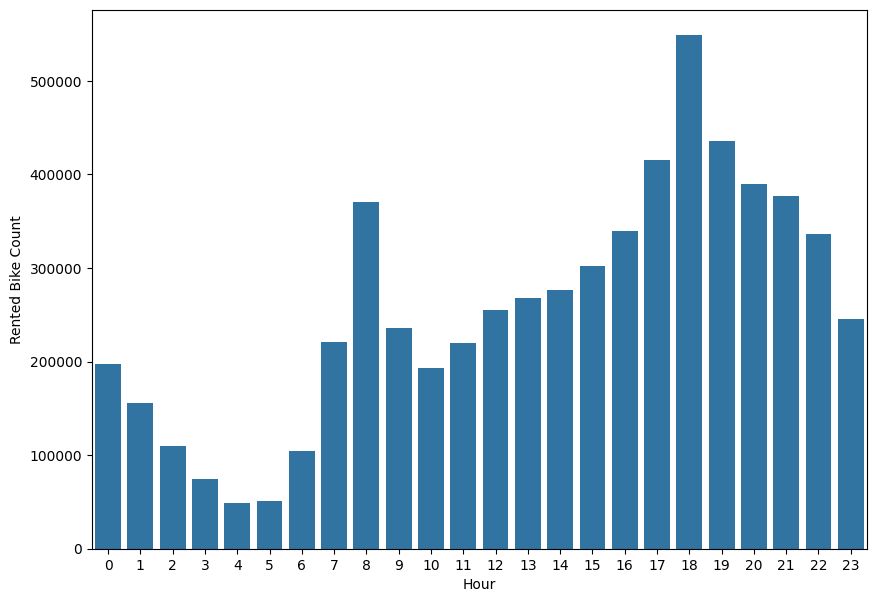

In [ ]:
Hour = df.groupby("Hour").sum()
plt.figure(figsize=(10,7))
sns.barplot(x= "Hour" , y= "Rented Bike Count" , data= Hour)

# ✅ **Hour 17-19 (means 5-7 Pm )** representing **high bike demands**. highest rentals, likely office commute time

# ✅ **Hour 4 and 5 o'clock lowest** bike demand in city, minimal usage during late night or early morning

# ✅ **Morning peak around 8 AM** , secondary spike (work/school travel)

# ✅ **Demand steadily rises from noon to evening** , strong afternoon usage pattern

# ✅ **Post 7 PM decline** ,  rentals **decrease** after peak hours




# **✔ Chart no.5**

<Axes: xlabel='Holiday', ylabel='Rented Bike Count'>

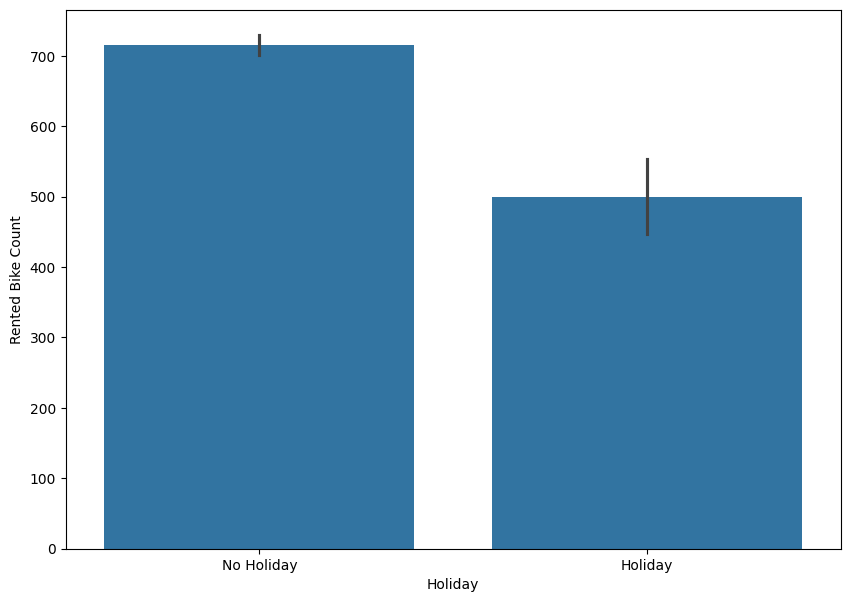

In [ ]:
plt.figure(figsize=(10,7))
sns.barplot(x = "Holiday" , y = "Rented Bike Count" , data= df)

# ✅ **On No holiday for 200 bikes is extra high demand** compare with holiday

# **✔ Chart no.6**

<Axes: xlabel='Seasons', ylabel='Rented Bike Count'>

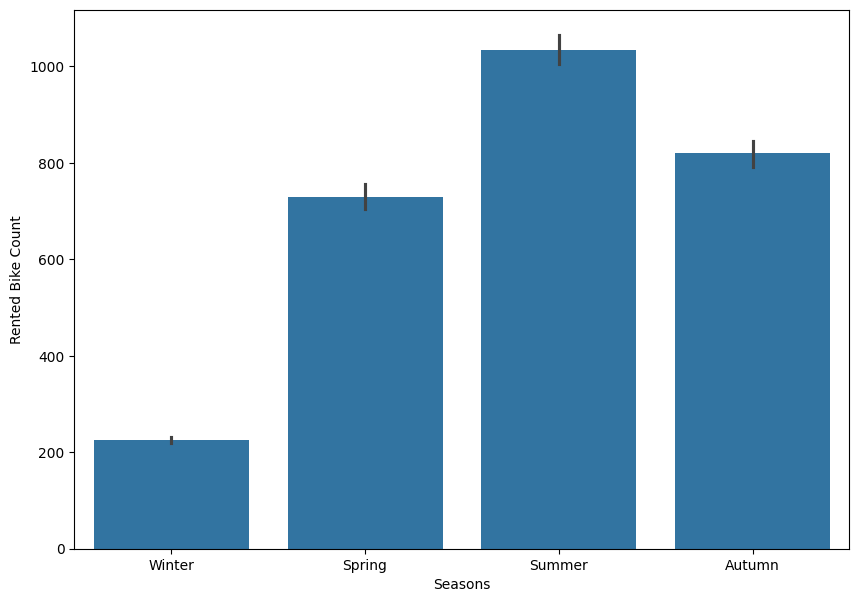

In [ ]:
plt.figure(figsize=(10,7))
sns.barplot(x="Seasons" , y= "Rented Bike Count", data = df)

# ✅ we having four seasons winter,spring,summer,autumn

# ✅ **Summer season shows high demand** for the rented bike as there is **less rainfall and snowfall** in city.

# ✅ **winter season reflects snowfall** in seoul so the **demand** for bike also **decreases.**

# ✅ Spring and autumn seasons have medium level of bike demand.

# **✔ Chart no.7**

<Axes: xlabel='Rented Bike Count', ylabel='Count'>

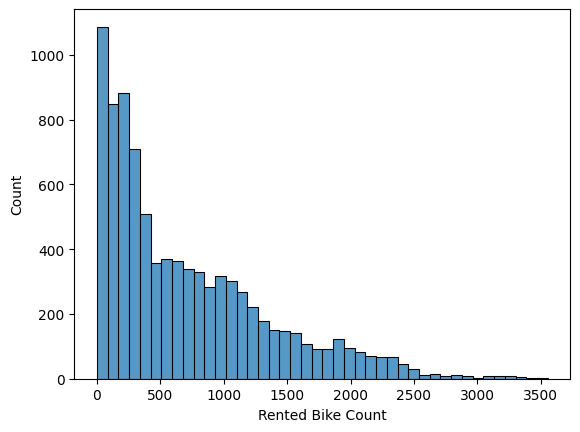

In [ ]:
sns.histplot(df["Rented Bike Count"])

# ✅   The distribution is **right-skewed**, meaning most days have lower rented bike counts, with a few days showing very high demand.

# There is a **long tail**, indicating occasional spikes in rentals, likely due to factors like weather, holidays, or events.


# **✔ Chart no.8**

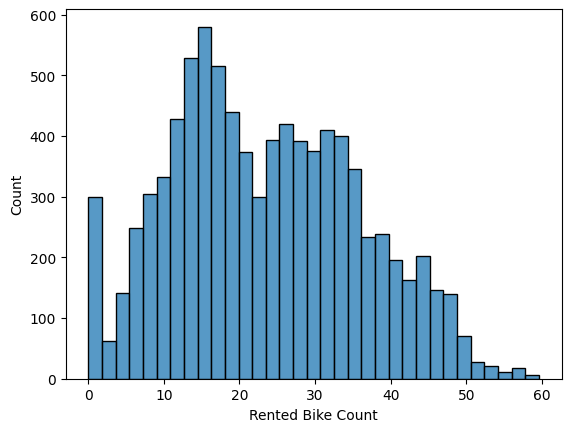

In [ ]:
sns.histplot(np.sqrt(df["Rented Bike Count"]))





# ✅ The peak rental activity occurs around **15 bikes**, showing this is the most common demand level.  

# ✅  The distribution is **right-skewed**, meaning higher rental counts are rare compared to lower ones.

# ✅  Rentals above **40 bikes** are very **infrequent**, highlighting limited instances of high demand.  

# ✅ The histogram suggests that **small to moderate rentals dominate usage patterns**, useful for resource planning.  


In [ ]:
df.select_dtypes(include=['number']).skew().sort_values(ascending= True)

,0
Year,-2.978262
Visibility (10m),-0.701786
Dew point temperature(°C),-0.367298
Temperature(°C),-0.198326
Month,-0.010458
Hour,0.000000
Day,0.007522
Humidity(%),0.059579
Wind speed (m/s),0.890955
Rented Bike Count,1.153428


# ▶ **Remove multi colinerity**

# **✔ Chart no.9**

<Axes: >

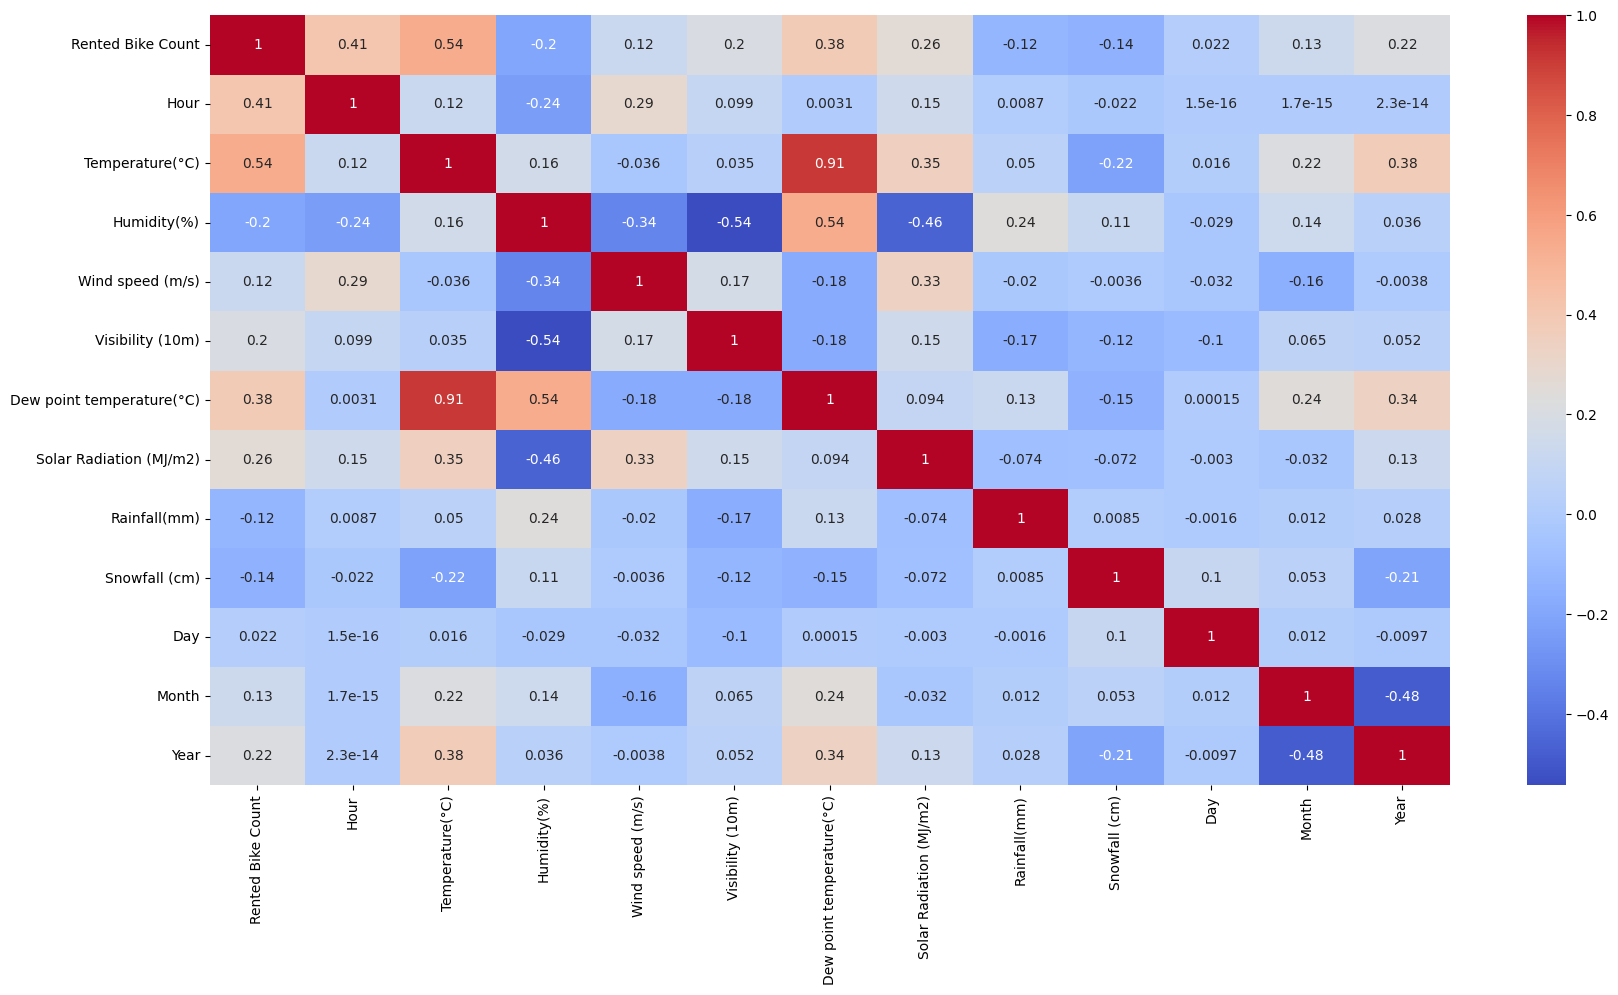

In [ ]:
plt.figure(figsize=(20 ,10))
sns.heatmap(df.select_dtypes(include=['number']).corr() , annot = True , cmap= "coolwarm")


# ✅ **Temperature (0.54) & Dew Point (0.38)** show **strong positive correlation** with bike rentals , **warmer conditions** significantly increase demand.

# ✅ **Humidity (-0.20), Snowfall (-0.14), Rainfall (-0.12)** **negatively impact **rentals , **bad weather** reduces usage.

# ✅ **Hour (0.41)** has a **good positive correlation** , rentals depend heavily on time of day (peak hours matter).

# ✅ **Solar Radiation (0.26) & Visibility (0.20)** positively influence demand ,  clearer, sunnier days boost rentals.

# ✅ **Temperature & Dew Point (0.91)** are highly correlated , avoid using both together to prevent multicollinearity.



# **Conclusion**



# ✅  **Focus on peak hours (8 AM & 5-7 PM)** it ensure maximum bike availability during commute times


# ✅ **Leverage summer months (May-Oct)** could  run promotions, expand fleet, and increase pricing strategically


# ✅  **Reduce impact of bad weather** by offering  discounts or incentives during rain, snow, or high humidity


# ✅  **Use weather-based demand prediction** for better planing  operations based on temperature & clear weather conditions


# ✅ **Optimize low-demand periods (night/winter)** by introduce offers, subscriptions, or alternate use cases


# ✅ **Final Strategy** is Combine **time + weather + seasonality** to maximize demand, pricing, and bike availability
